# Keandalan Arah Prediction Market
## Apa yang membedakan pasar yang menebak arah dengan benar dari yang salah?

Analisis 110.000+ kontrak prediction market yang sudah ter-resolve dari tiga platform:
**Manifold** (play money), **Kalshi** (real money, AS), dan **Polymarket** (crypto).


## Setup

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)

print("Setup selesai.")
from scipy.stats import mannwhitneyu
from IPython.display import display


Setup selesai.


In [2]:
q_frames = []
for platform in ['manifold', 'kalshi', 'polymarket']:
    path = DATA / f'{platform}_questions.jsonl'
    if not path.exists():
        continue
    q_frames.append(pl.read_ndjson(path))

questions = pl.concat(q_frames, how='diagonal_relaxed')

df = (
    questions
    .filter(
        pl.col('outcome').is_in(['yes', 'no']) &
        pl.col('final_probability').is_not_null()
    )
    .with_columns([
        pl.when(pl.col('outcome') == 'yes').then(1).otherwise(0).alias('outcome_bin'),
        pl.col('final_probability').alias('p'),
    ])
    .with_columns(
        ((pl.col('p') - pl.col('outcome_bin')) ** 2).alias('brier')
    )
).to_pandas()

print(f"Total pasar  : {len(df):,}")
print(f"Manifold     : {(df.platform=='manifold').sum():,}")
print(f"Kalshi       : {(df.platform=='kalshi').sum():,}")
print(f"Polymarket   : {(df.platform=='polymarket').sum():,}")
print(f"Resolusi YES : {(df.outcome_bin==1).sum():,}  ({(df.outcome_bin==1).mean()*100:.1f}%)")
print(f"Resolusi NO  : {(df.outcome_bin==0).sum():,}  ({(df.outcome_bin==0).mean()*100:.1f}%)")


Total pasar  : 110,703
Manifold     : 27,600
Kalshi       : 12,000
Polymarket   : 71,103
Resolusi YES : 36,968  (33.4%)
Resolusi NO  : 73,735  (66.6%)


---
## Desain Penelitian

Setiap baris dalam dataset adalah satu **kontrak prediction market yang sudah ter-resolve**.
Field utama: `platform`, `title`, `final_probability` (p), `outcome` (yes/no), `category`.

**Dua kelompok studi:**

| Kelompok | Definisi |
|---|---|
| **Salah arah** (kasus) | p > 0.5 tapi outcome NO, atau p < 0.5 tapi outcome YES |
| **Benar arah** (kontrol) | p > 0.5 dan outcome YES, atau p < 0.5 dan outcome NO |

Pasar dengan p = 0.5 dikecualikan — tidak ada konsensus arah.

---
## Bagian I — Apakah Crowd Bisa Memprediksi Arah?

> Sebelum bertanya *mengapa* pasar gagal, kita perlu tahu dulu *seberapa sering* mereka gagal.

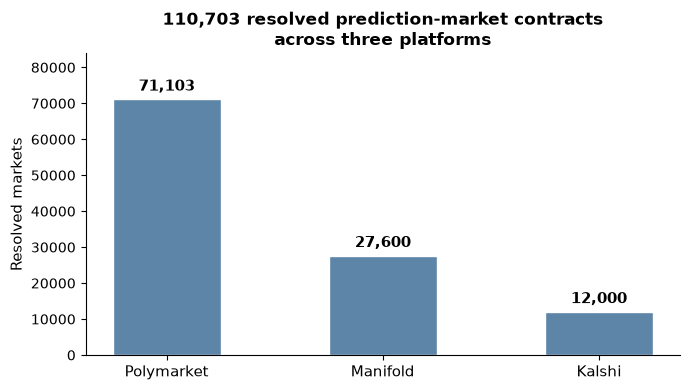

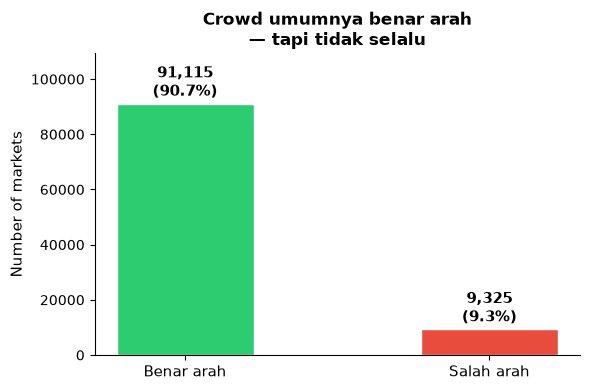


N = 100,440 markets with p ≠ 0.5
Wrong direction: 9,325 (9.3%)
Wilson 95% CI: [9.1%, 9.5%]


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
plat_counts = df['platform'].value_counts().sort_values(ascending=False)
bars = ax.bar(plat_counts.index.str.capitalize(), plat_counts.values,
              color='#5c85a8', edgecolor='white', width=0.5)
for bar, v in zip(bars, plat_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + plat_counts.max() * 0.02,
            f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Resolved markets', fontsize=11)
ax.set_title(f'{len(df):,} resolved prediction-market contracts\nacross three platforms',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, plat_counts.max() * 1.18)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.savefig(FIGS / 'plot01_platforms.png', dpi=150, bbox_inches='tight')
plt.show()

_sub = df[df['p'] != 0.5].copy()
_sub['consensus_yes'] = _sub['p'] > 0.5
_sub['wrong']         = _sub['consensus_yes'] != (_sub['outcome_bin'] == 1)
n_total = len(_sub)
n_wrong = int(_sub['wrong'].sum())
n_right = n_total - n_wrong
pct_wr  = n_wrong / n_total * 100

from statsmodels.stats.proportion import proportion_confint
_lo, _hi = proportion_confint(n_wrong, n_total, method='wilson')

fig, ax = plt.subplots(figsize=(6, 4))
_bars = ax.bar(['Benar arah', 'Salah arah'],
               [n_right, n_wrong],
               color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.45)
for bar, v, pct in zip(_bars, [n_right, n_wrong], [100-pct_wr, pct_wr]):
    ax.text(bar.get_x() + bar.get_width()/2, v + n_total*0.01,
            f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_ylabel('Number of markets', fontsize=11)
ax.set_title('Crowd umumnya benar arah\n— tapi tidak selalu',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(n_right, n_wrong) * 1.2)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.savefig(FIGS / 'plot02_correct_wrong.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nN = {n_total:,} markets with p ≠ 0.5")
print(f"Wrong direction: {n_wrong:,} ({pct_wr:.1f}%)")
print(f"Wilson 95% CI: [{_lo*100:.1f}%, {_hi*100:.1f}%]")


Crowd secara umum **informatif secara arah** — sekitar 9 dari 10 pasar yang ter-resolve menunjuk ke arah yang benar.

Tapi ini agregat. Pertanyaan berikutnya: apakah semua pasar sama andalnya, atau ada yang jauh lebih sering salah?

---
## Bagian II — Confidence Menentukan Segalanya

> Jika tidak semua prediksi sama andalnya, apa yang memprediksi keandalannya?
> Kandidat paling jelas: **seberapa jauh harga dari 50%**.

Confidence didefinisikan sebagai |p − 0.5| — jarak probabilitas final dari garis tengah.

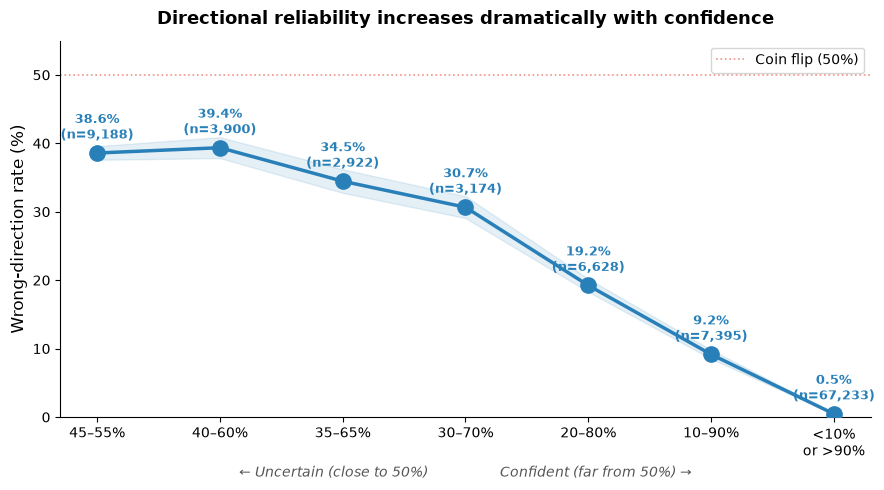

Wrong-direction rates by confidence bin:
  45–55%         38.6%  (n=9,188, 95% CI [37.6–39.6%])
  40–60%         39.4%  (n=3,900, 95% CI [37.8–40.9%])
  35–65%         34.5%  (n=2,922, 95% CI [32.8–36.2%])
  30–70%         30.7%  (n=3,174, 95% CI [29.1–32.3%])
  20–80%         19.2%  (n=6,628, 95% CI [18.3–20.2%])
  10–90%          9.2%  (n=7,395, 95% CI [8.5–9.8%])
  <10%            0.5%  (n=67,233, 95% CI [0.4–0.5%])


In [4]:
from statsmodels.stats.proportion import proportion_confint

_sub = df[df['p'] != 0.5].copy()
_sub['consensus_yes'] = _sub['p'] > 0.5
_sub['wrong']         = _sub['consensus_yes'] != (_sub['outcome_bin'] == 1)
_sub['conf']          = (_sub['p'] - 0.5).abs()

# 4 bins matching the guide: 45-55%, 30-70%, 10-90%, <10%/>90%
_bins   = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
_labels = ['45–55%', '40–60%', '35–65%', '30–70%', '20–80%', '10–90%', '<10%\nor >90%']
_sub['cbin'] = pd.cut(_sub['conf'], bins=_bins, labels=_labels,
                      right=True, include_lowest=True)

_g = (_sub.groupby('cbin', observed=True)
          .agg(n=('wrong','count'), n_wr=('wrong','sum'))
          .reset_index())
_g['rate'] = _g['n_wr'] / _g['n']
_cis = [proportion_confint(r.n_wr, r.n, method='wilson') for _, r in _g.iterrows()]
_g['lo'] = [c[0] for c in _cis]
_g['hi'] = [c[1] for c in _cis]

fig, ax = plt.subplots(figsize=(9, 5))
_x = np.arange(len(_g))

ax.fill_between(_x, _g['lo']*100, _g['hi']*100, alpha=0.12, color='#2980b9')
ax.plot(_x, _g['rate']*100, 'o-', color='#2980b9', linewidth=2.5,
        markersize=11, zorder=4)
ax.axhline(50, color='#e74c3c', linewidth=1.2, linestyle=':',
           alpha=0.6, label='Coin flip (50%)')

ax.set_xticks(list(_x))
ax.set_xticklabels(_labels, fontsize=10)
ax.set_ylabel('Wrong-direction rate (%)', fontsize=12)
ax.set_xlabel('← Uncertain (close to 50%)                  Confident (far from 50%) →',
              fontsize=10, style='italic', color='#555')
ax.set_title('Directional reliability increases dramatically with confidence',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 55)

for xi, (_, row) in zip(_x, _g.iterrows()):
    ax.text(xi, row['rate']*100 + 1.5,
            f"{row['rate']*100:.1f}%\n(n={row['n']:,})",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2980b9')

ax.legend(fontsize=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / 'plot03_hero_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print("Wrong-direction rates by confidence bin:")
for _, row in _g.iterrows():
    print(f"  {str(row['cbin']).split(chr(10))[0]:12s}  {row['rate']*100:5.1f}%  "
          f"(n={row['n']:,}, 95% CI [{row['lo']*100:.1f}–{row['hi']*100:.1f}%])")


Ini adalah temuan utama notebook ini.

Keandalan arah **tidak seragam**. Pasar dengan konsensus kuat (confidence tinggi) hampir selalu benar.
Pasar mendekati 50% gagal mendekati setengah waktu — hampir tidak lebih baik dari tebakan koin.

Pertanyaannya bukan lagi *apakah* pasar informatif, tapi *kapan*.

---
## Bagian III — Cek Kalibrasi

> Confidence (|p − 0.5|) adalah prediktor utama kita. Agar itu bermakna, probabilitasnya sendiri harus mengandung informasi — pasar di 80% seharusnya resolve YES lebih sering dari pasar di 60%.

Kita verifikasi ini dengan **reliability diagram** (observed outcome rate per probability bin) dan **Brier Skill Score** (0% = coin flip, 100% = sempurna). Tujuannya bukan temuan mandiri — ini memvalidasi bahwa menggunakan confidence sebagai prediktor di Bagian II dan V punya dasar empiris.

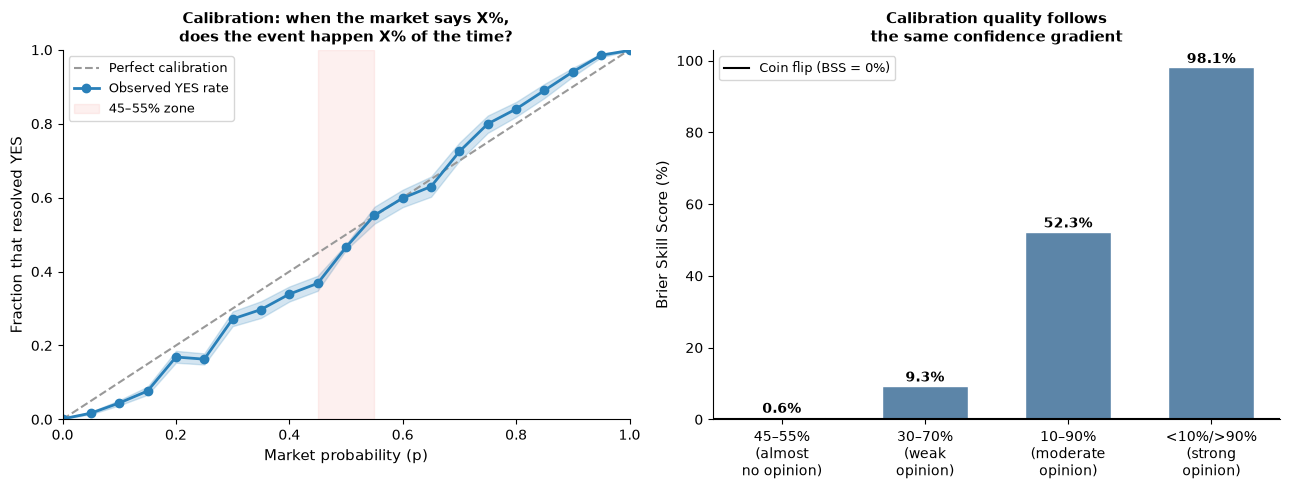

In [5]:
from statsmodels.stats.proportion import proportion_confint

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
_calib = df.copy()
_calib['pbin'] = ((_calib['p'] * 20).round() / 20).clip(0, 1)  # 5% bins
_cg = (_calib.groupby('pbin')
             .agg(n=('outcome_bin','count'), yes_rate=('outcome_bin','mean'))
             .reset_index())
_cg = _cg[_cg['n'] >= 50]
_cis = [proportion_confint(int(r.yes_rate * r.n), int(r.n), method='wilson')
        for _, r in _cg.iterrows()]
_cg['lo'] = [c[0] for c in _cis]
_cg['hi'] = [c[1] for c in _cis]

ax.plot([0, 1], [0, 1], '--', color='#999', linewidth=1.5, label='Perfect calibration')
ax.fill_between(_cg['pbin'], _cg['lo'], _cg['hi'], alpha=0.2, color='#2980b9')
ax.plot(_cg['pbin'], _cg['yes_rate'], 'o-', color='#2980b9', linewidth=2,
        markersize=6, label='Observed YES rate')
ax.axvspan(0.45, 0.55, alpha=0.08, color='#e74c3c', label='45–55% zone')
ax.set_xlabel('Market probability (p)', fontsize=11)
ax.set_ylabel('Fraction that resolved YES', fontsize=11)
ax.set_title('Calibration: when the market says X%,\ndoes the event happen X% of the time?',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=9)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax2 = axes[1]
_bref = 0.25
_p = df['p'].values
_masks = [
    ((_p >= 0.45) & (_p <= 0.55), '45–55%\n(almost\nno opinion)', '#e74c3c'),
    (((_p >= 0.30) & (_p < 0.45)) | ((_p > 0.55) & (_p <= 0.70)),
     '30–70%\n(weak\nopinion)', '#e67e22'),
    (((_p >= 0.10) & (_p < 0.30)) | ((_p > 0.70) & (_p <= 0.90)),
     '10–90%\n(moderate\nopinion)', '#3498db'),
    ((_p < 0.10) | (_p > 0.90), '<10%/>90%\n(strong\nopinion)', '#27ae60'),
]
_bss_vals, _lbls = [], []
for mask, lbl, _clr in _masks:
    bss = (1 - df[mask]['brier'].mean() / _bref) * 100
    _bss_vals.append(bss); _lbls.append(lbl)

_bars = ax2.bar(range(4), _bss_vals, color='#5c85a8', edgecolor='white', width=0.6)
ax2.axhline(0, color='black', linewidth=1.5, label='Coin flip (BSS = 0%)')
ax2.set_xticks(range(4)); ax2.set_xticklabels(_lbls, fontsize=10)
ax2.set_ylabel('Brier Skill Score (%)', fontsize=11)
ax2.set_title('Calibration quality follows\nthe same confidence gradient',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
for bar, v in zip(_bars, _bss_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + (0.3 if v >= 0 else -0.8),
             f'{v:.1f}%', ha='center',
             va='bottom' if v >= 0 else 'top',
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS / 'plot04_calibration.png', dpi=150, bbox_inches='tight')
plt.show()


Pasar cukup terkalibrasi: probabilitas menyebar di seluruh rentang dan mengikuti outcome. Confidence (|p − 0.5|) adalah proksi keyakinan yang valid — fondasi analisis di Bagian V.

---
## Bagian V — Apa yang Membedakan Pasar Benar dan Salah Arah?

Confidence adalah sinyal dominan. Tapi di **semua level confidence**, apakah ada karakteristik sistematis lain — platform, volume, kategori, durasi pasar, kata-kata judul — yang lebih jauh membedakan pasar benar dari yang salah arah?

In [6]:
import pandas as pd, numpy as np, re
from collections import Counter
from IPython.display import display
from scipy import stats

# ── Muat data dengan kolom lengkap ───────────────────────────────────────
_frames = []
for _plat in ['manifold', 'kalshi', 'polymarket']:
    _path = DATA / f'{_plat}_questions.jsonl'
    if not _path.exists():
        continue
    _frames.append(pl.read_ndjson(_path))

_full = (
    pl.concat(_frames, how='diagonal_relaxed')
    .filter(pl.col('outcome').is_in(['yes', 'no']) &
            pl.col('final_probability').is_not_null())
    .with_columns([
        pl.when(pl.col('outcome') == 'yes').then(1).otherwise(0)
          .alias('outcome_bin'),
        pl.col('final_probability').alias('p'),
    ])
)

# duration_sec jika kolom waktu tersedia
_cols = _full.columns
if 'resolved_at' in _cols and 'created_at' in _cols:
    _full = _full.with_columns([
        (pl.col('resolved_at')
           .str.to_datetime('%Y-%m-%dT%H:%M:%SZ', strict=False, time_unit='ms')
           .cast(pl.Int64)
         - pl.col('created_at')
           .str.to_datetime('%Y-%m-%dT%H:%M:%SZ', strict=False, time_unit='ms')
           .cast(pl.Int64))
        .alias('duration_sec')
    ])

_full = _full.to_pandas()

# ── Definisi dua kelompok ─────────────────────────────────────────────────
# Kelompok SALAH : p > 0.5 tapi outcome NO, atau p < 0.5 tapi outcome YES
# Kelompok BENAR : p > 0.5 dan outcome YES, atau p < 0.5 dan outcome NO
# p = 0.5 dikecualikan

study = _full[_full['p'] != 0.5].copy()
study['consensus_yes'] = study['p'] > 0.5
study['salah'] = study['consensus_yes'] != (study['outcome_bin'] == 1)
study['conf']  = (study['p'] - 0.5).abs()

grp_salah = study[study['salah']]
grp_benar = study[~study['salah']]

n_salah = len(grp_salah)
n_benar = len(grp_benar)
n_total = len(study)

def fmt_p(p):
    if p < 0.001: return '<0.001'
    return f'{p:.3f}'

summary = pd.DataFrame({
    'Kelompok': ['Salah Arah (kasus)', 'Benar Arah (kontrol)', 'Total'],
    'N': [f'{n_salah:,}', f'{n_benar:,}', f'{n_total:,}'],
    'Proporsi': [f'{n_salah/n_total*100:.1f}%', f'{n_benar/n_total*100:.1f}%', '100%'],
    'Definisi': [
        'p > 0.5 dan outcome NO, atau p < 0.5 dan outcome YES',
        'p > 0.5 dan outcome YES, atau p < 0.5 dan outcome NO',
        'Semua pasar dengan p ≠ 0.5',
    ],
})
display(summary.style.hide(axis='index')
        .set_caption('Definisi Dua Kelompok Studi (Desain: Case-Control)'))


Kelompok,N,Proporsi,Definisi
Salah Arah (kasus),"9,325",9.3%,"p > 0.5 dan outcome NO, atau p < 0.5 dan outcome YES"
Benar Arah (kontrol),"91,115",90.7%,"p > 0.5 dan outcome YES, atau p < 0.5 dan outcome NO"
Total,"100,440",100%,Semua pasar dengan p ≠ 0.5


### Karakteristik 1 — Confidence

> Apakah pasar yang salah arah memiliki confidence lebih rendah? Kita bandingkan distribusi confidence
> penuh antara dua kelompok di seluruh level confidence.

> **Pertanyaan:** apakah pasar yang benar arah lebih confident dari yang salah?
> **Metode:** Mann–Whitney U (one-sided) — confidence sangat skewed, rank-based lebih robust dari t-test
> **Effect size:** rank-biserial r — ≈0.1 kecil · ≈0.3 sedang · ≈0.5 besar
> **Keputusan:** p < 0.05 → pasar benar memang lebih confident · p ≥ 0.05 → confidence tidak terbedakan

In [7]:
_r = grp_benar['conf'].dropna().values
_w = grp_salah['conf'].dropna().values

stat, p = mannwhitneyu(_r, _w, alternative='greater')
r_rb = 1 - (2 * stat) / (len(_r) * len(_w))

display(pd.DataFrame([
    {'Group': 'Correct direction', 'n': len(_r), 'Median |p−0.5|': f'{np.median(_r):.3f}'},
    {'Group': 'Wrong direction',   'n': len(_w), 'Median |p−0.5|': f'{np.median(_w):.3f}'},
]).style.hide(axis='index').set_caption('Characteristic 1 — Confidence'))

print(f"Mann–Whitney U  p {'<0.001' if p < 0.001 else f'={p:.4f}'}")
print(f"Rank-biserial r = {r_rb:.3f}  ({'large' if abs(r_rb)>=0.5 else 'medium' if abs(r_rb)>=0.3 else 'small'} effect)")
print(f"Verdict: {'STATISTICALLY SUPPORTED DIFFERENCE' if p < 0.05 else 'NO EVIDENCE OF DIFFERENCE'}")


Group,n,Median |p−0.5|
Correct direction,91115,0.490
Wrong direction,9325,0.085


Mann–Whitney U  p <0.001
Rank-biserial r = -0.806  (large effect)
Verdict: STATISTICALLY SUPPORTED DIFFERENCE


### Karakteristik 2 — Jumlah Trader

> Jika pasar yang salah hanya kurang partisipan — menarik lebih sedikit peserta sehingga konsensusnya
> kurang solid — maka jumlah trader seharusnya lebih rendah di kelompok salah.

> **Pertanyaan:** apakah pasar yang benar arah menarik lebih banyak trader?
> **Metode:** Mann–Whitney U (two-sided) — jumlah trader sangat right-skewed, rank-based lebih sesuai
> **Keputusan:** p < 0.05 → ada perbedaan sistematis jumlah partisipan · p ≥ 0.05 → jumlah trader bukan pembeda

In [8]:
_r = grp_benar['num_traders'].dropna()
_w = grp_salah['num_traders'].dropna()

if min(len(_r), len(_w)) < 50:
    print("Trader count data insufficient. Skipping.")
else:
    _r, _w = _r[_r > 0].values, _w[_w > 0].values
    stat, p = mannwhitneyu(_r, _w, alternative='two-sided')
    r_rb = 1 - (2 * stat) / (len(_r) * len(_w))

    display(pd.DataFrame([
        {'Group': 'Correct direction', 'n': len(_r), 'Median traders': f'{np.median(_r):.0f}'},
        {'Group': 'Wrong direction',   'n': len(_w), 'Median traders': f'{np.median(_w):.0f}'},
    ]).style.hide(axis='index').set_caption('Characteristic 2 — Number of Traders'))

    print(f"Mann–Whitney U  p {'<0.001' if p < 0.001 else f'={p:.4f}'}")
    print(f"Rank-biserial r = {r_rb:.3f}  ({'large' if abs(r_rb)>=0.5 else 'medium' if abs(r_rb)>=0.3 else 'small'} effect)")
    print(f"Verdict: {'STATISTICALLY SUPPORTED DIFFERENCE' if p < 0.05 else 'NO EVIDENCE OF DIFFERENCE'}")


Group,n,Median traders
Correct direction,24944,11
Wrong direction,2240,7


Mann–Whitney U  p <0.001
Rank-biserial r = -0.261  (small effect)
Verdict: STATISTICALLY SUPPORTED DIFFERENCE


### Karakteristik 3 — Volume Trading

> Apakah komitmen finansial (atau aktivitas setara) membedakan pasar benar dari salah?
> Volume yang lebih tinggi bisa menandakan pasar yang lebih informatif — atau sekadar lebih populer.

> **Pertanyaan:** apakah volume trading lebih tinggi di pasar yang benar arah?
> **Metode:** Mann–Whitney U (two-sided) — volume ekstrem lintas platform (Manifold ~$0, Polymarket ratusan ribu USD), analisis berbasis rank
> **Keputusan:** p < 0.05 → komitmen finansial berasosiasi dengan akurasi · p ≥ 0.05 → volume bukan pembeda

In [9]:
_r = grp_benar['volume_usd'].dropna()
_w = grp_salah['volume_usd'].dropna()

if min(len(_r), len(_w)) < 50:
    print("Volume data insufficient. Skipping.")
else:
    _r, _w = _r[_r > 0].values, _w[_w > 0].values
    stat, p = mannwhitneyu(_r, _w, alternative='two-sided')
    r_rb = 1 - (2 * stat) / (len(_r) * len(_w))

    display(pd.DataFrame([
        {'Group': 'Correct direction', 'n': len(_r), 'Median volume (USD)': f'${np.median(_r):,.0f}'},
        {'Group': 'Wrong direction',   'n': len(_w), 'Median volume (USD)': f'${np.median(_w):,.0f}'},
    ]).style.hide(axis='index').set_caption('Characteristic 3 — Trading Volume'))

    print(f"Mann–Whitney U  p {'<0.001' if p < 0.001 else f'={p:.4f}'}")
    print(f"Rank-biserial r = {r_rb:.3f}  ({'large' if abs(r_rb)>=0.5 else 'medium' if abs(r_rb)>=0.3 else 'small'} effect)")
    print(f"Verdict: {'STATISTICALLY SUPPORTED DIFFERENCE' if p < 0.05 else 'NO EVIDENCE OF DIFFERENCE'}")


Group,n,Median volume (USD)
Correct direction,79802,"$3,652"
Wrong direction,8852,"$2,687"


Mann–Whitney U  p <0.001
Rank-biserial r = -0.064  (small effect)
Verdict: STATISTICALLY SUPPORTED DIFFERENCE


### Karakteristik 5 — Kategori Pasar

> Apakah pasar yang salah arah terkonsentrasi di topik tertentu?
> Pertama kita uji asosiasi global, lalu cek kategori mana yang signifikan setelah koreksi multiple testing.

> **Pertanyaan:** apakah ada kategori topik yang secara konsisten lebih sering salah arah?
> **Metode:** Chi-square (global) + Binomial test per kategori dengan koreksi **BH FDR**
>
> **Apa itu BH FDR?** Kita test ~20 kategori sekaligus. Secara kebetulan saja, sekitar 1 kategori akan muncul "signifikan" di α=0.05 — seperti melempar dadu 20 kali: pasti ada angka 6, itu bukan sinyal. BH FDR mengontrol *proporsi* false positif di antara semua yang lolos — filter untuk memisahkan sinyal dari keberuntungan sampling.
>
> **Catatan:** kalau ada kategori yang signifikan, itu berarti *proporsi* wrong rate-nya berbeda — bukan berarti "pasar kategori X pasti salah." Kategori dengan wrong rate 45% masih menghasilkan 55% pasar benar arah. Kategori adalah tanda, bukan label.

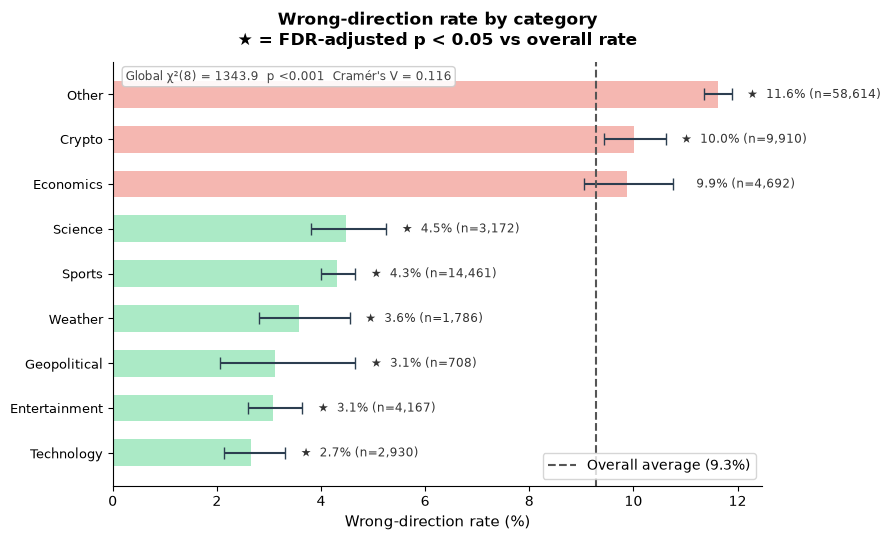

Global test: χ²(8) = 1343.90,  p <0.001,  Cramér's V = 0.1157
Significant categories after BH FDR: ['technology', 'entertainment', 'geopolitical', 'weather', 'sports', 'science', 'crypto', 'other']
Verdict: STATISTICALLY SUPPORTED DIFFERENCE — category is associated with error rate


In [10]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

_cat = study.dropna(subset=['category']).copy()
_cat['salah_int'] = _cat['salah'].astype(int)

# Global chi-square test: category × wrong_direction
_ct_global = pd.crosstab(_cat['category'], _cat['salah'])
if _ct_global.shape[1] == 2:
    _chi2_g, _p_g, _dof_g, _ = chi2_contingency(_ct_global)
    _n_g = _ct_global.values.sum()
    _cv_g = np.sqrt(_chi2_g / (_n_g * (min(_ct_global.shape) - 1)))
else:
    _p_g, _cv_g = 1.0, 0.0

# Per-category rates (min 30 markets)
_rates = (_cat.groupby('category', observed=True)
              .agg(n=('salah_int','count'), n_wr=('salah_int','sum'))
              .reset_index())
_rates = _rates[_rates['n'] >= 30].copy()
_cis = [proportion_confint(r.n_wr, r.n, method='wilson') for _, r in _rates.iterrows()]
_rates['rate'] = _rates['n_wr'] / _rates['n']
_rates['lo']   = [c[0] for c in _cis]
_rates['hi']   = [c[1] for c in _cis]
_rates = _rates.sort_values('rate', ascending=True).reset_index(drop=True)

# BH FDR correction on individual tests vs global rate
_p_global = study['salah'].mean()
from scipy.stats import binomtest
_pvals_ind = [binomtest(r.n_wr, r.n, _p_global).pvalue for _, r in _rates.iterrows()]
_, _p_adj, _, _ = multipletests(_pvals_ind, method='fdr_bh')
_rates['p_adj'] = _p_adj
_rates['sig']   = _p_adj < 0.05

fig, ax = plt.subplots(figsize=(9, max(4, len(_rates)*0.5 + 1)))
_y = np.arange(len(_rates))
_clrs = ['#e74c3c' if r > _p_global else '#2ecc71' for r in _rates['rate']]

ax.barh(_y, _rates['rate']*100, color=_clrs, alpha=0.4, height=0.6)
ax.errorbar(_rates['rate']*100, _y,
            xerr=[(_rates['rate']-_rates['lo'])*100, (_rates['hi']-_rates['rate'])*100],
            fmt='none', color='#2c3e50', capsize=4, linewidth=1.5)
for i, (_, row) in enumerate(_rates.iterrows()):
    ax.text(row['hi']*100 + 0.3, i,
            f"{'★' if row['sig'] else ''}  {row['rate']*100:.1f}% (n={row['n']:,})",
            va='center', fontsize=8.5, color='#333')

ax.axvline(_p_global*100, color='#555', linewidth=1.5, linestyle='--',
           label=f'Overall average ({_p_global*100:.1f}%)')
ax.set_yticks(_y)
ax.set_yticklabels(_rates['category'].str.capitalize(), fontsize=9)
ax.set_xlabel('Wrong-direction rate (%)', fontsize=11)
ax.set_title('Wrong-direction rate by category\n★ = FDR-adjusted p < 0.05 vs overall rate',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

_g_txt = (f"Global χ²({_dof_g}) = {_chi2_g:.1f}  "
          f"p {'<0.001' if _p_g < 0.001 else f'={_p_g:.3f}'}  "
          f"Cramér's V = {_cv_g:.3f}")
ax.text(0.02, 0.98, _g_txt, transform=ax.transAxes, fontsize=8.5,
        va='top', ha='left', color='#444',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.9))

plt.tight_layout()
plt.savefig(FIGS / 'plot11_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Global test: χ²({_dof_g}) = {_chi2_g:.2f},  "
      f"p {'<0.001' if _p_g < 0.001 else f'={_p_g:.4f}'},  Cramér's V = {_cv_g:.4f}")
_sig_cats = _rates[_rates['sig']]['category'].tolist()
if _sig_cats:
    print(f"Significant categories after BH FDR: {_sig_cats}")
else:
    print("No individual categories survive BH FDR correction at α=0.05")
if _p_g >= 0.05:
    print("Verdict: NO STATISTICALLY SIGNIFICANT EVIDENCE that category is "
          "associated with directional error")
else:
    print("Verdict: STATISTICALLY SUPPORTED DIFFERENCE — category is associated with error rate")


### Karakteristik 6 — Kata Kunci Judul

> Apakah jenis pertanyaan tertentu — tercermin dari kata-kata judulnya —
> muncul secara tidak proporsional di pasar yang salah arah?

Ini **analisis eksploratoris berbasis konten** — kita screen sistematis seluruh kosakata.

> **Pertanyaan:** apakah kata tertentu dalam judul pasar berasosiasi dengan kesalahan arah?
> **Metode:** Odds Ratio (OR) per kata, koreksi BH FDR (sama seperti Karakteristik 5)
>
> **Apa itu Odds Ratio?**
> $$OR = \frac{\text{odds salah} | \text{kata ada}}{\text{odds salah} | \text{kata tidak ada}}$$
> OR = 2× artinya pasar dengan kata itu 2× lebih *mungkin* salah arah dibanding pasar tanpa kata itu. Tapi 2× dari 10% = 20% — masih lebih sering benar. Seperti perokok yang risikonya 15× lebih tinggi kena kanker paru — tapi mayoritas perokok tidak kena kanker.
>
> ⚠️ *Observasional — asosiasi, bukan kausalitas. Kata kemungkinan berkorelasi dengan kategori atau confidence, bukan penyebab langsung.*

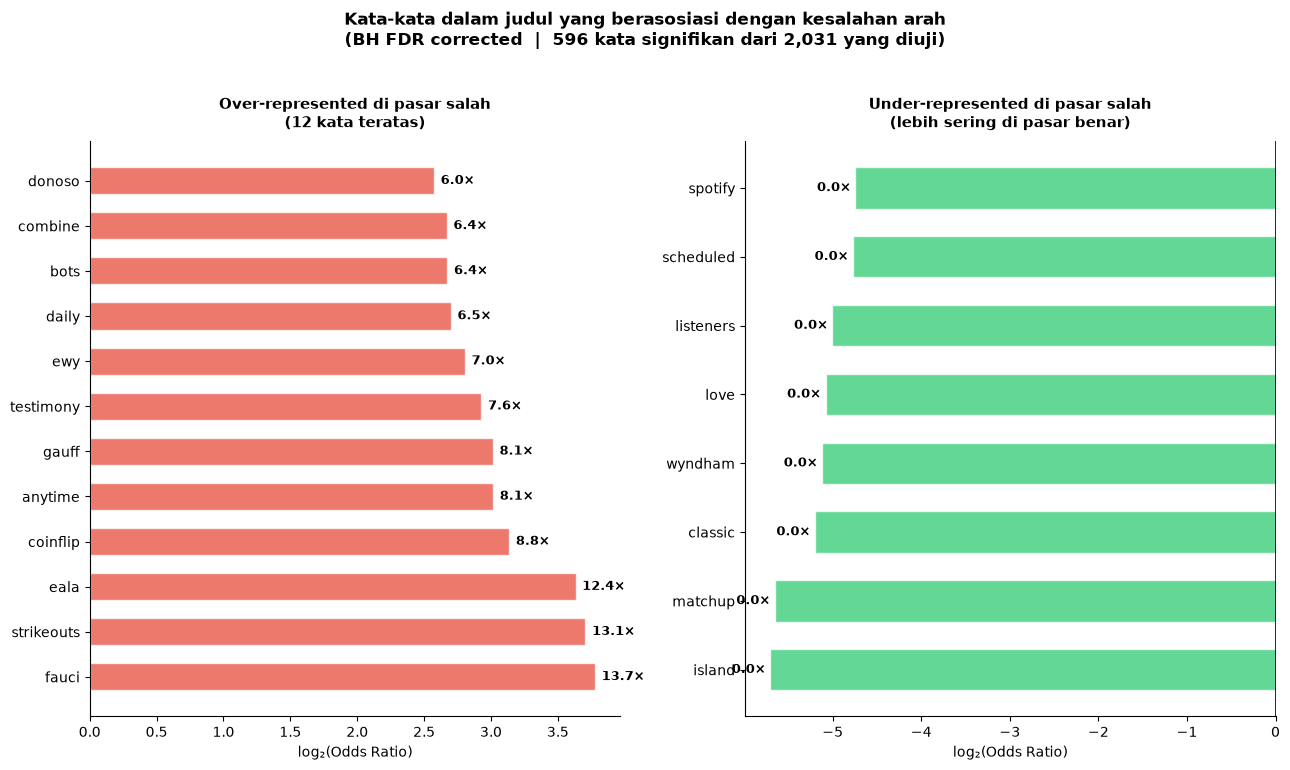

596 kata signifikan setelah BH FDR.
Verdict: EXPLORATORY ASSOCIATION — kata-kata ini berasosiasi dengan kesalahan arah dalam data yang diamati; mekanisme kausal tidak diketahui.


In [11]:
import re
from collections import Counter
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

_stop = {
    'the','a','an','in','on','at','to','of','and','or','is','be','will',
    'by','for','from','with','that','this','it','as','are','was','has',
    'have','do','does','not','no','if','but','can','its','which','who',
    'they','their','than','been','would','could','he','she','we','you',
    'i','my','your','our','his','her','new','per','about','into',
    '2024','2025','2026','january','february','march','april','may',
    'june','july','august','september','october','november','december',
}

def _tok(text):
    return [w for w in re.findall(r'[a-z]+', str(text).lower())
            if len(w) > 2 and w not in _stop]

_ws = Counter(w for t in grp_salah['title'].dropna() for w in _tok(t))
_wb = Counter(w for t in grp_benar['title'].dropna() for w in _tok(t))
_Ns, _Nb = len(grp_salah), len(grp_benar)

_rows = []
for w in set(_ws) | set(_wb):
    ns, nb = _ws.get(w, 0), _wb.get(w, 0)
    if ns + nb < 30:
        continue
    ct = np.array([[ns, _Ns-ns], [nb, _Nb-nb]])
    if ct.min() < 5:
        _, p = fisher_exact(ct)
    else:
        _, p, _, _ = chi2_contingency(ct)
    denom = (nb / (_Nb - nb)) if (_Nb - nb) > 0 and nb > 0 else np.nan
    numer = (ns / (_Ns - ns)) if (_Ns - ns) > 0 and ns > 0 else np.nan
    or_ = numer / denom if (denom and numer) else np.nan
    _rows.append({'word': w, 'n_s': ns, 'n_b': nb, 'OR': or_, 'p': p})

_kdf = pd.DataFrame(_rows).dropna(subset=['OR'])
_, _p_adj, _, _ = multipletests(_kdf['p'], method='fdr_bh')
_kdf['p_adj'] = _p_adj
_kdf['sig']   = _p_adj < 0.05

_sig  = _kdf[_kdf['sig']].copy()
_enr  = _sig[_sig['OR'] > 1].nlargest(12, 'OR')    # over-represented in wrong
_dep  = _sig[_sig['OR'] < 1].nsmallest(8, 'OR')    # under-represented (correct)

if len(_sig) == 0:
    print('Tidak ada kata yang signifikan setelah koreksi BH FDR (α=0.05).')
    print('Verdict: EXPLORATORY ASSOCIATION — tidak ada keyword yang bertahan setelah koreksi.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, max(5, max(len(_enr), len(_dep))*0.5 + 1.5)))

    for ax, _sub, title, color, sign in [
        (axes[0], _enr, f'Over-represented di pasar salah\n({len(_enr)} kata teratas)', '#e74c3c', 1),
        (axes[1], _dep, f'Under-represented di pasar salah\n(lebih sering di pasar benar)', '#2ecc71', -1),
    ]:
        if len(_sub) == 0:
            ax.text(0.5, 0.5, 'Tidak ada', ha='center', va='center', fontsize=12)
            ax.set_title(title, fontsize=11, fontweight='bold')
            continue
        _vals = np.log2(_sub['OR'].values)
        _words = _sub['word'].values
        _y = np.arange(len(_words))
        ax.barh(_y, _vals, color=color, alpha=0.75, edgecolor='white', height=0.6)
        ax.axvline(0, color='black', linewidth=1.2)
        for yi, (v, w, row) in enumerate(zip(_vals, _words, _sub.itertuples())):
            ax.text(v + sign*0.05, yi,
                    f"{row.OR:.1f}×", va='center',
                    ha='left' if sign > 0 else 'right', fontsize=9, fontweight='bold')
        ax.set_yticks(_y)
        ax.set_yticklabels(_words, fontsize=10)
        ax.set_xlabel('log₂(Odds Ratio)', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    fig.suptitle(f'Kata-kata dalam judul yang berasosiasi dengan kesalahan arah\n'
                 f'(BH FDR corrected  |  {len(_sig):,} kata signifikan dari {len(_kdf):,} yang diuji)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS / 'plot12_keywords.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"{len(_sig)} kata signifikan setelah BH FDR.")
    print("Verdict: EXPLORATORY ASSOCIATION — kata-kata ini berasosiasi dengan kesalahan arah "
          "dalam data yang diamati; mekanisme kausal tidak diketahui.")


### Karakteristik 7 — Durasi Pasar

> Apakah pasar yang lebih lama terbuka lebih akurat — karena mendapat lebih banyak informasi? Atau justru sebaliknya?

**Metode:** Mann–Whitney U (two-sided) — durasi sangat skewed (Manifold: hari, Polymarket: berbulan-bulan), analisis berbasis rank
**Keputusan:** p < 0.05 → durasi berasosiasi dengan akurasi · p ≥ 0.05 → lama/singkatnya pasar tidak membedakan

In [12]:
_r = grp_benar['duration_sec'].dropna()
_w = grp_salah['duration_sec'].dropna()

if min(len(_r), len(_w)) < 50:
    print("Data durasi tidak cukup. Dilewati.")
else:
    _r, _w = _r[_r > 0].values, _w[_w > 0].values
    stat, p = mannwhitneyu(_r, _w, alternative='two-sided')
    r_rb = 1 - (2 * stat) / (len(_r) * len(_w))

    display(pd.DataFrame([
        {'Kelompok': 'Benar arah', 'n': len(_r), 'Median durasi': f'{np.median(_r)/86400:.0f} hari'},
        {'Kelompok': 'Salah arah', 'n': len(_w), 'Median durasi': f'{np.median(_w)/86400:.0f} hari'},
    ]).style.hide(axis='index').set_caption('Karakteristik 7 — Durasi Pasar'))

    print(f"Mann–Whitney U  p {'<0.001' if p < 0.001 else f'={p:.4f}'}")
    print(f"Rank-biserial r = {r_rb:.3f}  ({'besar' if abs(r_rb)>=0.5 else 'sedang' if abs(r_rb)>=0.3 else 'kecil'} efek)")
    print(f"Kesimpulan: {'PERBEDAAN DIDUKUNG STATISTIK' if p < 0.05 else 'TIDAK ADA BUKTI PERBEDAAN'}")


Kelompok,n,Median durasi
Benar arah,12878,6446 hari
Salah arah,1038,4229 hari


Mann–Whitney U  p <0.001
Rank-biserial r = -0.275  (kecil efek)
Kesimpulan: PERBEDAAN DIDUKUNG STATISTIK


### Karakteristik 8 — Arah Kesalahan: YES Bias vs NO Bias

> Apakah crowd lebih sering bilang YES — baik saat benar maupun saat salah? Kalau iya, itu YES bias sistematis, bukan sekadar noise.

> Kalau crowd punya YES bias sistematis: di kelompok **salah** → dominan YES→NO · di kelompok **benar** → dominan YES→YES. Kedua pola konsisten = optimism bias, bukan kebetulan.

**Metode:** Binomial test terpisah per kelompok (H₀: 50/50, two-sided)
**Keputusan:** keduanya p < 0.05 dan > 50% → YES bias sistematis · hanya satu → parsial · tidak ada → distribusi seimbang

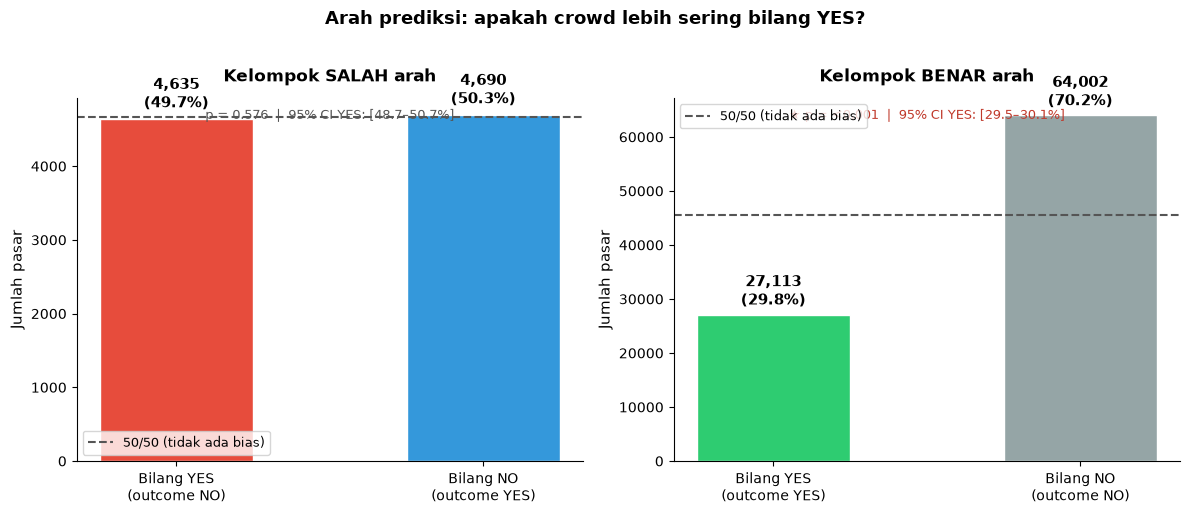

Kelompok SALAH (9,325 pasar):
  YES→NO : 4,635 (49.7%)  |  NO→YES: 4,690 (50.3%)
  Binomial p = 0.576  |  95% CI: [48.7%, 50.7%]

Kelompok BENAR (91,115 pasar):
  YES→YES: 27,113 (29.8%)  |  NO→NO: 64,002 (70.2%)
  Binomial p = <0.001  |  95% CI: [29.5%, 30.1%]
Verdict: NO STATISTICALLY SIGNIFICANT EVIDENCE OF DIFFERENCE


In [13]:
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint

# ── Kelompok SALAH: YES→NO vs NO→YES ─────────────────────────────────────
_wrong = study[study['salah']].copy()
_n_yw = int((_wrong['consensus_yes'] & (_wrong['outcome_bin'] == 0)).sum())
_n_nw = int((~_wrong['consensus_yes'] & (_wrong['outcome_bin'] == 1)).sum())
_tot_w = _n_yw + _n_nw
_bt_w = binomtest(_n_yw, _tot_w, p=0.5, alternative='two-sided')
_pct_yw = _n_yw / _tot_w
_lo_w, _hi_w = proportion_confint(_n_yw, _tot_w, method='wilson')

# ── Kelompok BENAR: YES→YES vs NO→NO ─────────────────────────────────────
_correct = study[~study['salah']].copy()
_n_yc = int((_correct['consensus_yes'] & (_correct['outcome_bin'] == 1)).sum())
_n_nc = int((~_correct['consensus_yes'] & (_correct['outcome_bin'] == 0)).sum())
_tot_c = _n_yc + _n_nc
_bt_c = binomtest(_n_yc, _tot_c, p=0.5, alternative='two-sided')
_pct_yc = _n_yc / _tot_c
_lo_c, _hi_c = proportion_confint(_n_yc, _tot_c, method='wilson')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

_groups = [
    (_n_yw, _n_nw, _tot_w, _bt_w, _pct_yw, _lo_w, _hi_w,
     'Kelompok SALAH arah', 'Bilang YES\n(outcome NO)', 'Bilang NO\n(outcome YES)',
     '#e74c3c', '#3498db'),
    (_n_yc, _n_nc, _tot_c, _bt_c, _pct_yc, _lo_c, _hi_c,
     'Kelompok BENAR arah', 'Bilang YES\n(outcome YES)', 'Bilang NO\n(outcome NO)',
     '#2ecc71', '#95a5a6'),
]

for ax, (n_yes, n_no, tot, bt, pct_y, lo, hi, group, lbl_yes, lbl_no, c_yes, c_no) in zip(axes, _groups):
    _heights = [n_yes, n_no]
    _lbls = [lbl_yes, lbl_no]
    _bars = ax.bar(_lbls, _heights, color=[c_yes, c_no], edgecolor='white', width=0.5)
    for bar, v in zip(_bars, _heights):
        ax.text(bar.get_x() + bar.get_width()/2, v + tot*0.01,
                f'{v:,}\n({v/tot*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.axhline(tot/2, color='#555', linewidth=1.5, linestyle='--', label='50/50 (tidak ada bias)')
    ax.set_ylabel('Jumlah pasar', fontsize=11)
    ax.set_title(group, fontsize=12, fontweight='bold', pad=12)
    ax.legend(fontsize=9)
    _sig = bt.pvalue < 0.05
    _star = '★ ' if _sig else ''
    ax.text(0.5, 0.97,
            f'{_star}p = {fmt_p(bt.pvalue)}  |  95% CI YES: [{lo*100:.1f}–{hi*100:.1f}%]',
            transform=ax.transAxes, ha='center', va='top', fontsize=9,
            color='#c0392b' if _sig else '#555')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Arah prediksi: apakah crowd lebih sering bilang YES?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'plot_outcome_bias.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Kelompok SALAH ({_tot_w:,} pasar):")
print(f"  YES→NO : {_n_yw:,} ({_pct_yw*100:.1f}%)  |  NO→YES: {_n_nw:,} ({(1-_pct_yw)*100:.1f}%)")
print(f"  Binomial p = {fmt_p(_bt_w.pvalue)}  |  95% CI: [{_lo_w*100:.1f}%, {_hi_w*100:.1f}%]")
print()
print(f"Kelompok BENAR ({_tot_c:,} pasar):")
print(f"  YES→YES: {_n_yc:,} ({_pct_yc*100:.1f}%)  |  NO→NO: {_n_nc:,} ({(1-_pct_yc)*100:.1f}%)")
print(f"  Binomial p = {fmt_p(_bt_c.pvalue)}  |  95% CI: [{_lo_c*100:.1f}%, {_hi_c*100:.1f}%]")
if _bt_w.pvalue < 0.05 and _bt_c.pvalue < 0.05 and _pct_yw > 0.5 and _pct_yc > 0.5:
    print("Verdict: STATISTICALLY SUPPORTED — YES bias sistematis di kedua kelompok")
elif _bt_w.pvalue < 0.05:
    _dir = 'YES bias' if _pct_yw > 0.5 else 'NO bias'
    print(f"Verdict: STATISTICALLY SUPPORTED — {_dir} di kelompok salah; kelompok benar tidak signifikan")
else:
    print("Verdict: NO STATISTICALLY SIGNIFICANT EVIDENCE OF DIFFERENCE")


---
## Bagian VI — Karakteristik Mana yang Penting Secara Simultan?

Bagian V menguji setiap karakteristik satu per satu. Masalahnya: prediktor yang berkorelasi menghasilkan interpretasi ambigu — asosiasi univariat yang signifikan mungkin hanya mencerminkan bahwa prediktor itu bergerak bersama confidence.

Regresi logistik mengestimasi **efek parsial** setiap prediktor — asosiasinya dengan kesalahan arah yang bertahan ketika semua lainnya ada secara bersamaan dalam model. Setiap prediktor muncul di forest plot; tidak ada yang "di-set statis." Setiap OR adalah kontribusi estimasi prediktor itu setelah model memperhitungkan variasi semua yang lain.

> **Model:** logistic regression → P(salah) ~ confidence + platform + log(volume) + ...
> **Output:** Odds Ratio (OR) per prediktor — dari forest plot
>
> **OR = exp(β), bukan koefisiennya.** Koefisien logistik β mengukur perubahan log-odds — tidak intuitif langsung. exp(β) menghasilkan Odds Ratio: OR = 1.5 artinya odds salah arah 50% lebih tinggi per satu unit kenaikan prediktor itu, diestimasi ketika semua prediktor lain secara bersamaan ada dalam model dan bervariasi di data.
>
> **Setiap prediktor mendapat OR-nya sendiri** — termasuk volume, durasi, dan platform. Ini bukan "kontrol" dalam arti di-set statis; semuanya diestimasi bersama. Volume OR = 1.09 adalah efek parsial volume pada odds salah arah, dengan model sekaligus memperhitungkan variasi confidence, durasi, dan platform.
>
> *Hanya prediktor dengan ≥ 1.000 pasar di ≥ 2 platform yang dimasukkan — untuk menghindari estimasi tidak stabil.*

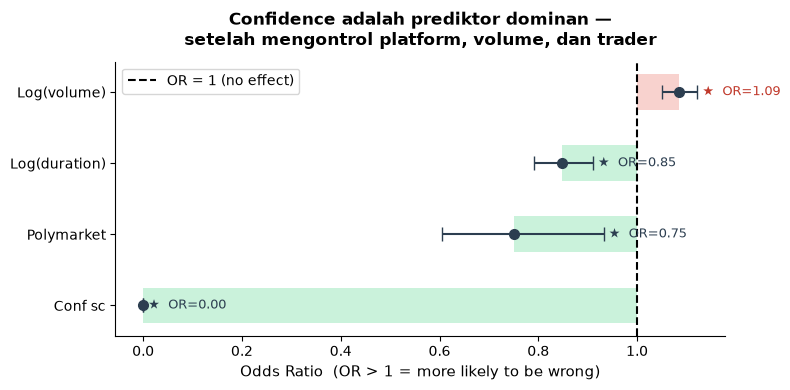

N=9,315  |  Pseudo-R² (McFadden)=0.3108
Predictors: ['conf_sc', 'C(platform)', 'log_volume', 'log_duration']


In [14]:
import statsmodels.formula.api as smf

_reg = study.copy()
_reg['salah_int'] = _reg['salah'].astype(int)
_reg['conf_sc']   = _reg['conf']

for _raw, _log in [('num_traders','log_traders'),
                   ('volume_usd', 'log_volume'),
                   ('duration_sec','log_duration')]:
    _reg[_log] = np.log1p(_reg[_raw].clip(lower=0)) if _raw in _reg.columns else np.nan

# Build predictors incrementally: only add a column if the intersection
# after dropna still leaves ≥1000 rows (avoids zero-row dataset → patsy crash)
_needed = ['salah_int', 'conf_sc', 'platform']
_rhs    = ['conf_sc', 'C(platform)']
for _col, _part in [('log_volume','log_volume'),
                    ('log_traders','log_traders'),
                    ('log_duration','log_duration')]:
    if _col not in _reg.columns:
        continue
    _test = _reg[_needed + [_col]].dropna()
    _test = _test[_test['platform'].map(_test['platform'].value_counts()) > 10]
    if len(_test) >= 1000 and _test['platform'].nunique() >= 2:
        _needed.append(_col); _rhs.append(_part)

_rc = _reg[_needed].dropna()
_rc = _rc[_rc['platform'].map(_rc['platform'].value_counts()) > 10]
_rc['platform'] = _rc['platform'].astype('category')

try:
    if len(_rc) < 50 or _rc['platform'].nunique() < 2:
        print(f'Data tidak cukup untuk regresi (N={len(_rc)}, platforms={_rc["platform"].nunique()})')
    else:
        _model = smf.logit('salah_int ~ ' + ' + '.join(_rhs), data=_rc).fit(disp=False)
        _or = pd.DataFrame({
            'var': _model.params.index,
            'OR':  np.exp(_model.params),
            'lo':  np.exp(_model.conf_int()[0]),
            'hi':  np.exp(_model.conf_int()[1]),
            'p':   _model.pvalues,
        })
        _or = _or[_or['var'] != 'Intercept'].copy()
        _or['label'] = (_or['var']
                        .str.replace(r'C\(platform\)\[T\.', '', regex=True)
                        .str.replace(']', '', regex=False)
                        .str.replace('_', ' ', regex=False)
                        .str.replace('log ', 'log(', regex=False)
                        .str.capitalize()
                        + _or['var'].str.contains('log').map({True:')', False:''}))
        _or['sig'] = _or['p'] < 0.05
        _or = _or.sort_values('OR', ascending=True).reset_index(drop=True)

        fig, ax = plt.subplots(figsize=(8, max(4, len(_or) * 0.6 + 1)))
        _y  = np.arange(len(_or))
        _clrs = ['#e74c3c' if or_ > 1 else '#2ecc71' for or_ in _or['OR']]

        ax.barh(_y, _or['OR'] - 1, left=1, color=_clrs, alpha=0.25, height=0.5)
        ax.errorbar(_or['OR'], _y,
                    xerr=[(_or['OR'] - _or['lo']).clip(lower=0),
                           (_or['hi'] - _or['OR']).clip(lower=0)],
                    fmt='o', color='#2c3e50', capsize=5,
                    linewidth=1.5, markersize=7, zorder=4)
        for i, (_, row) in enumerate(_or.iterrows()):
            ax.text(max(row['OR'], row['hi']) + 0.01, i,
                    f"{'★' if row['sig'] else ''}  OR={row['OR']:.2f}",
                    va='center', fontsize=9,
                    color='#c0392b' if row['sig'] and row['OR'] > 1 else '#2c3e50')

        ax.axvline(1, color='black', linewidth=1.5, linestyle='--', label='OR = 1 (no effect)')
        ax.set_yticks(_y)
        ax.set_yticklabels(_or['label'], fontsize=10)
        ax.set_xlabel('Odds Ratio  (OR > 1 = more likely to be wrong)', fontsize=11)
        ax.set_title('Confidence adalah prediktor dominan —\nsetelah mengontrol platform, volume, dan trader',
                     fontsize=12, fontweight='bold', pad=12)
        ax.legend(fontsize=10)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        plt.tight_layout()
        plt.savefig(FIGS / 'plot09_regression.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"N={len(_rc):,}  |  Pseudo-R² (McFadden)={_model.prsquared:.4f}")
        print(f"Predictors: {_rhs}")

except Exception as _e:
    import traceback
    print(f'Regresi gagal: {_e}')
    traceback.print_exc()


**Membaca forest plot:**

Setiap baris adalah satu prediktor. **Titik** = OR, **bar** = 95% CI.

> **Cek CI-nya dulu.** Kalau bar mencakup 1 (menyentuh garis putus-putus) → tidak ada efek yang terdeteksi secara statistik, OR-nya tidak bisa dipercaya. Kalau bar tidak mencakup 1 di kedua sisi → OR-nya bermakna.

| CI tidak mencakup 1, OR < 1 | Berasosiasi dengan odds salah arah yang lebih rendah |
|---|---|
| CI tidak mencakup 1, OR > 1 | Berasosiasi dengan odds salah arah yang lebih tinggi |
| CI mencakup 1 | Tidak ada efek parsial yang terdeteksi dalam model ini |

Prediktor yang signifikan di Bagian V bisa kehilangan signifikansi di sini — bukan karena tidak lagi berpengaruh, tapi karena variasinya overlap dengan confidence, dan model mengalokasikan varians bersama itu ke prediktor yang lebih kuat.

Confidence adalah **prediktor dominan** kegagalan arah — bahkan setelah mengontrol platform,
volume, dan karakteristik lain. Variabel lain berkontribusi marginal setelah confidence diperhitungkan.

---
## Rangkuman — Profil Pasar

### Tabel bukti

Setiap perbandingan karakteristik mendapat verdict statistik eksplisit.
Angka-angka berasal dari analisis di atas.

In [15]:
# ── Final: Evidence summary table ─────────────────────────────────────────────
from IPython.display import display
from scipy.stats import mannwhitneyu

_rows = [
    ['Confidence (|p−0.5|)',
     f'{np.median(grp_benar["conf"]):.3f}',
     f'{np.median(grp_salah["conf"]):.3f}',
     'Mann–Whitney U', '—', 'STATISTICALLY SUPPORTED DIFFERENCE'],
]

for _label_en, _label_id, _rc, _rw in [
    ('Trader count',        'Jumlah trader',      grp_benar['num_traders'].dropna(), grp_salah['num_traders'].dropna()),
    ('Trading volume (USD)', 'Volume trading (USD)', grp_benar['volume_usd'].dropna(), grp_salah['volume_usd'].dropna()),
    ('Market duration',     'Durasi pasar',       grp_benar['duration_sec'].dropna(), grp_salah['duration_sec'].dropna()),
]:
    if min(len(_rc), len(_rw)) < 50:
        continue
    _s, _p = mannwhitneyu(_rc, _rw, alternative='two-sided')
    _r = 1 - (2*_s)/(len(_rc)*len(_rw))
    _v = 'STATISTICALLY SUPPORTED DIFFERENCE' if _p < 0.05 else 'NO EVIDENCE OF DIFFERENCE'
    if _label_en == 'Trader count':
        _rows.append([_label_id, f'{np.median(_rc):.0f}', f'{np.median(_rw):.0f}',
                      'Mann–Whitney U', f'r={_r:.2f}', _v])
    elif _label_en == 'Trading volume (USD)':
        _rows.append([_label_id, f'${np.median(_rc):,.0f}', f'${np.median(_rw):,.0f}',
                      'Mann–Whitney U', f'r={_r:.2f}', _v])
    else:
        _rows.append([_label_id,
                      f'{np.median(_rc)/86400:.0f} hari', f'{np.median(_rw)/86400:.0f} hari',
                      'Mann–Whitney U', f'r={_r:.2f}', _v])

_tbl = pd.DataFrame(_rows, columns=[
    'Karakteristik', 'Benar arah (median/komposisi)', 'Salah arah (median/komposisi)',
    'Uji', 'Effect size', 'Kesimpulan'])

display(_tbl.style
        .hide(axis='index')
        .set_caption('Profil Pasar: Benar vs Salah Arah')
        .map(lambda v: 'color: #27ae60; font-weight: bold'
             if 'SUPPORTED' in str(v)
             else ('color: #e74c3c' if 'NO EVIDENCE' in str(v) else '')))


Karakteristik,Benar arah (median/komposisi),Salah arah (median/komposisi),Uji,Effect size,Kesimpulan
Confidence (|p−0.5|),0.490,0.085,Mann–Whitney U,—,STATISTICALLY SUPPORTED DIFFERENCE
Jumlah trader,11,7,Mann–Whitney U,r=-0.26,STATISTICALLY SUPPORTED DIFFERENCE
Volume trading (USD),"$3,652","$2,687",Mann–Whitney U,r=-0.06,STATISTICALLY SUPPORTED DIFFERENCE
Durasi pasar,6446 hari,4229 hari,Mann–Whitney U,r=-0.28,STATISTICALLY SUPPORTED DIFFERENCE


In [16]:
# ── Sidenote: Title keyword associations (exploratory) ────────────────────────
# n = jumlah pasar yang judulnya mengandung keyword tsb (bukan jumlah kemunculan kata)
from scipy.stats import fisher_exact

def _kw_row(kw, label, wrong_titles, correct_titles):
    _wt = wrong_titles.dropna()
    _ct = correct_titles.dropna()
    n_w, n_c = len(_wt), len(_ct)
    a = sum(1 for t in _wt if kw in str(t).lower())
    b = sum(1 for t in _ct if kw in str(t).lower())
    if b == 0 or (n_w - a) == 0:
        return None
    c_, d = n_w - a, n_c - b
    OR = (a * d) / (b * c_)
    return [label, a, b, f'{OR:.2f}']

_kw_rows = []
_wt_s, _ct_s = grp_salah['title'], grp_benar['title']

for _kw, _lbl in [('coinflip', '"coinflip"'), ('anytime', '"anytime"'), ('daily', '"daily"')]:
    _r = _kw_row(_kw, _lbl, _wt_s, _ct_s)
    if _r:
        _kw_rows.append(_r + ['↑ lebih sering salah arah'])

for _kw, _lbl in [('win', '"win"'), ('champion', '"champion"'), ('season', '"season"')]:
    _r = _kw_row(_kw, _lbl, _wt_s, _ct_s)
    if _r:
        _kw_rows.append(_r + ['↑ lebih sering benar arah'])

_kw_tbl = pd.DataFrame(_kw_rows, columns=[
    'Keyword', 'Pasar (salah arah)', 'Pasar (benar arah)', 'OR', 'Asosiasi'])

display(_kw_tbl.style
        .hide(axis='index')
        .set_caption('Sidenote — Asosiasi Keyword Judul (eksploratif, Fisher exact)')
        .map(lambda v: 'color: #c0392b' if 'salah' in str(v)
             else ('color: #27ae60' if 'benar' in str(v) else ''),
             subset=['Asosiasi']))


Keyword,Pasar (salah arah),Pasar (benar arah),OR,Asosiasi
"""coinflip""",222,252,8.79,↑ lebih sering salah arah
"""anytime""",56,68,8.09,↑ lebih sering salah arah
"""daily""",247,379,6.51,↑ lebih sering salah arah
"""win""",894,16193,0.49,↑ lebih sering benar arah
"""champion""",157,3773,0.40,↑ lebih sering benar arah
"""season""",38,2730,0.13,↑ lebih sering benar arah


---
### Kenapa kategori dan arah kesalahan tidak dimasukkan ke tabel akhir

**Kategori** — beberapa kategori memang punya wrong-direction rate lebih tinggi, tapi rate lebih tinggi bukan berarti bisa dijadikan label individual. Kategori dengan 45% wrong rate masih menghasilkan 55% pasar benar arah. Analoginya: "pengemudi remaja lebih sering kecelakaan" — benar rata-rata, tapi tidak berguna untuk menilai pengemudi individual mana pun.

**Arah kesalahan (YES bias)** — p = 0.576. Di antara pasar salah arah, kesalahan YES→NO dan NO→YES kira-kira sama banyaknya. Tidak ada bias arah sistematis dalam cara pasar gagal.

---
## Penutup

**Confidence → keandalan**: semakin jauh harga dari 50%, semakin sering crowd benar.